NETWORK INTRUSION DETECTION SYSTEM
Monitoring network for 30 seconds...

[ALERT] SYN Flood/Port Scan detected from 192.168.4.245
[RESPONSE] Blocked IP: 192.168.4.245

Monitoring Finished.

Attack Log Saved as attack_logs.csv
       Time             IP     Attack
0  14:23:27  192.168.4.245  SYN Flood


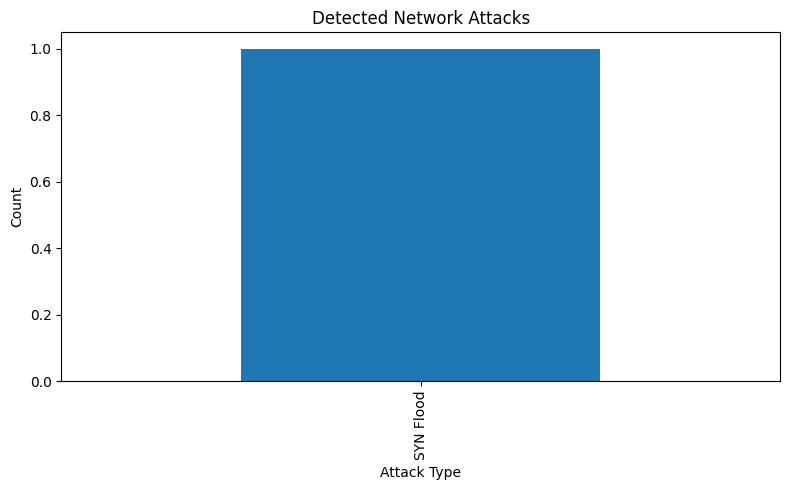

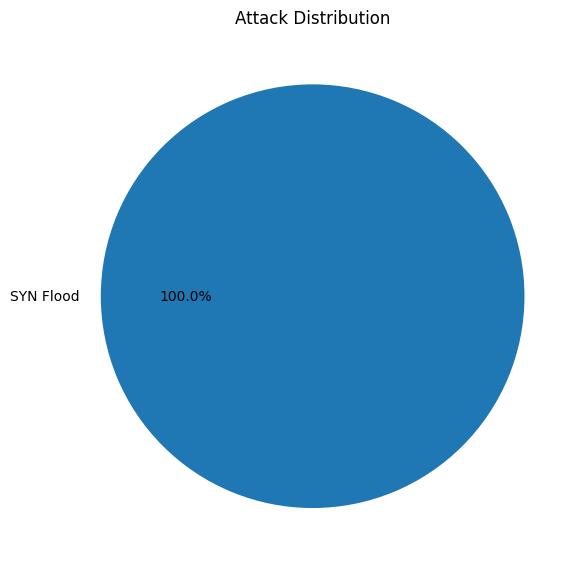

In [1]:
from scapy.all import sniff, IP, TCP, UDP, ICMP
from collections import defaultdict
import time
import os
import platform
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Configuration
# -----------------------------

CAPTURE_TIME = 30          # seconds
SYN_THRESHOLD = 20         # SYN packets before alert
ICMP_THRESHOLD = 15        # ICMP packets before alert

syn_counter = defaultdict(int)
icmp_counter = defaultdict(int)

alerts = []

print("=" * 60)
print("NETWORK INTRUSION DETECTION SYSTEM")
print("=" * 60)
print("Monitoring network for 30 seconds...\n")

# -----------------------------
# Block Attacker IP
# -----------------------------

def block_ip(ip):

    system = platform.system()

    try:

        if system == "Windows":

            cmd = f'netsh advfirewall firewall add rule name="Block_{ip}" dir=in action=block remoteip={ip}'
            os.system(cmd)

        elif system == "Linux":

            cmd = f"sudo iptables -A INPUT -s {ip} -j DROP"
            os.system(cmd)

        print(f"[RESPONSE] Blocked IP: {ip}")

    except Exception as e:
        print(e)

# -----------------------------
# Packet Analysis
# -----------------------------

def detect(packet):

    if IP not in packet:
        return

    src = packet[IP].src

    # -------------------------
    # TCP SYN Scan Detection
    # -------------------------

    if TCP in packet:

        tcp = packet[TCP]

        if tcp.flags == "S":

            syn_counter[src] += 1

            if syn_counter[src] == SYN_THRESHOLD:

                print(f"[ALERT] SYN Flood/Port Scan detected from {src}")

                alerts.append(
                    {
                        "Time": time.strftime("%H:%M:%S"),
                        "IP": src,
                        "Attack": "SYN Flood"
                    }
                )

                block_ip(src)

    # -------------------------
    # ICMP Flood Detection
    # -------------------------

    if ICMP in packet:

        icmp_counter[src] += 1

        if icmp_counter[src] == ICMP_THRESHOLD:

            print(f"[ALERT] ICMP Flood detected from {src}")

            alerts.append(
                {
                    "Time": time.strftime("%H:%M:%S"),
                    "IP": src,
                    "Attack": "ICMP Flood"
                }
            )

            block_ip(src)

    # -------------------------
    # Suspicious Ports
    # -------------------------

    if TCP in packet:

        suspicious_ports = [21,22,23,445,3389]

        if packet[TCP].dport in suspicious_ports:

            attack = f"Access to Port {packet[TCP].dport}"

            print(f"[ALERT] {attack} from {src}")

            alerts.append(
                {
                    "Time": time.strftime("%H:%M:%S"),
                    "IP": src,
                    "Attack": attack
                }
            )

# -----------------------------
# Start Capture
# -----------------------------

sniff(prn=detect,
      timeout=CAPTURE_TIME,
      store=False)

print("\nMonitoring Finished.")

# -----------------------------
# Save Logs
# -----------------------------

if len(alerts) == 0:

    print("\nNo threats detected.")

else:

    df = pd.DataFrame(alerts)

    df.to_csv("attack_logs.csv", index=False)

    print("\nAttack Log Saved as attack_logs.csv")

    print(df)

    # -------------------------
    # Visualization
    # -------------------------

    attack_counts = df["Attack"].value_counts()

    plt.figure(figsize=(8,5))
    attack_counts.plot(kind="bar")

    plt.title("Detected Network Attacks")
    plt.xlabel("Attack Type")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,6))

    attack_counts.plot(kind="pie",
                       autopct="%1.1f%%")

    plt.ylabel("")
    plt.title("Attack Distribution")

    plt.tight_layout()

    plt.show()